::: {.content-hidden}
Project: ML In Production
Group Project

For this project, you will work in small teams to develop a production machine learning project. In this project you will be playing the role of a data science and data engineering team working at ‘citibike’, which provides bike sharing services in NYC. An interesting aspect of ‘citibike’ is that it is a hybrid between a business which earns revenue, and a part of the public transport infrastructure of ‘NYC’. Owing to its hybrid nature, citibike provides a wealth of public data which can be used to solve data science problems relating both to business and to municipal governance.

Your projects will be developed and deployed on a class-specific ‘databricks’/‘AWS’ workspace which has been logging the status of citibike stations every 5 minutes and station information each day using the citibike ‘GBFS’ feed. You will also have access to other data, including trip data and weather data accessible through ‘bigquery’, and any data that you think you might need for your project.

The timeline for the project is as follows:

    Team Formation (Weeks 1-4, by September 27th). This will take place on the course slack page. Ideal teams will be 3 or 4 students. You should message your classmates and post what problems you are interested in working on. If at the end of Week 4 you are unable to find a team, you must contact me and I will assign you to a team. It is important to be thinking about your project idea and working towards your project proposal towards the end of this phase. After you form your team, I will send you an invitation to a GitHub Classroom and DataBricks workspace.
:::

::: {.content-hidden}
    Project Proposal (October 4th, 10%). You will develop and submit a project proposal with a maximum length of 3 pages (not including references). The proposal should define the problem and outline your proposed solution. It should also answer as best as possible the following questions:

        What type of Machine Learning problem will you solve, and how might citibike, New York City, or New Yorkers use the outputs? You do not necessarily have to achieve these goals but they are useful to have in mind.

        What data sources are you planning to use, and which if any external data sources will you add? Each project is required to add at least one additional data set/data source and make it available as a documented table in the shared catalog for other teams to potentially use.

        What initial approach/model types will you use to solve the problem?

        How will you evaluate model performance?

        Will model training be online (model updates whenever new data is ingested) or batch (at scheduled intervals)?

        Do you anticipate any large computational needs? If you think you will need to use large neural network models, LLMs, GPUs/TPUs, make sure to let me know here.

        The key midterm check for this project is the development of a minimally viable product, which will demonstrate feasibility and which you will iteratively improve. What does your minimally viable product look like?
:::

::: {.content-hidden}
    Midterm Check In (November 2nd-7th, 20%) You will present/demonstrate a minimal viable product version (MVP) of your system to your professor. Your presentation should be about 10 minutes long. The first part should be a slideshow presentation (target 5 minutes and 3 slides) which pitches your project, gives a diagram of your proposed solution, and outlines what challenges remain. The second part is a 5 minute demo of your MVP. It is ok if your MVP is very basic, ideally I want to see that you have given good thought to your application, tried to make your MVP an end-to-end product, and have a good understanding of the challenges that await. Afterwards there will be a question and answer session about your project.

    Production Deployment and Final Presentation (November 16th to December 14th, 50%) Projects should be deployed in production starting on November 16th and their performance monitored for 4 weeks. This production period will culminate in a final presentation which will be scheduled with your professor during the week of the 14th. The presentation will include an introduction to your system, a live-demo, and a question and answer with the instructor about your project and codebase. Your final presentation should include measures of model performance from the production period.

    Project Writeup/Documentation (December 18th, 20%): The documentation for this project shall consist of four things:

    A short model card which describes the model, its intended purpose, training data, and performance. Follow the format of ‘skops’ or read the paper that introduced the concept here Model Cards for Model Reporting. Standardized model documentation is common across a variety of industries including banking, medicine, and artificial intelligence (where the model card is typical).
    A datasheet which documents the dataset(s) that you collected to support your project. This should describe the motivation, composition, collection process, and intended uses. See the guide here Datasheets for Datasets. Think of this as a data dictionary but with additional information on the provenance and purpose of the dataset.
    A short runbook which describes the mechanics of your production system, i.e. what jobs run and when, where fitted models, logs, and performance measures are stored, etc.
    A whitepaper/technical blog post. Target length of 2000 words. This aims to be less formal than an academic research paper. You should have sections of the problem definition, system design, machine learning components, application demonstration (ideally you can integrate parts of your application into your report), and a conclusion/reflection. A great example of a whitepaper (though not an app) is here offgrid ai. Some great examples of reports are here, here, and here.

:::

In [29]:
#| label: mount-drive
#| include: false



# ── COLAB SETUP ──────────────────────────────────────────────────────────────
# In Colab: mount Google Drive and move into the project folder.
# On a local machine: do nothing, the notebook already sits next to the data.
import os
from pathlib import Path

try:
    from google.colab import drive
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    drive.mount("/content/drive")

    # Each teammate may keep the folder in a different place.
    # Add your own path to this list: the first one that exists wins.
    CANDIDATES = [
        "/content/drive/MyDrive/Colab Notebooks/Data 622 Project",
        "/content/drive/MyDrive/Data 622 Project",
    ]
    project_dir = next((p for p in CANDIDATES if Path(p).exists()), None)

    if project_dir is None:
        # Show what Drive holds, so the right path is easy to spot
        print("Project folder not found. Top of My Drive:")
        for p in sorted(Path("/content/drive/MyDrive").iterdir()):
            print("  ", p.name)
        raise FileNotFoundError("Add your project folder path to CANDIDATES.")

    os.chdir(project_dir)
    print("Working in:", os.getcwd())


In [30]:
#| label: check-packages
#| include: false

#  Pre-flight

# ── PACKAGE CHECK ────────────────────────────────────────────────────────────
# Checks that every package this notebook needs is installed.
# Anything missing gets installed with pip into the same Python the kernel uses.
import importlib
import importlib.util
import shutil
import subprocess
import sys

# import name : pip name (they differ for some packages, like sklearn)
REQUIRED = {
    "pandas":   "pandas",
    "numpy":    "numpy",
    "plotnine": "plotnine",
    "pyarrow":  "pyarrow",   # engine behind pd.read_parquet
}

# find_spec looks for a package without importing it
missing = [pip_name for import_name, pip_name in REQUIRED.items()
           if importlib.util.find_spec(import_name) is None]

if missing:
    print("Installing:", ", ".join(missing))
    # sys.executable is the kernel's own Python, so the install lands in the right place
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])
    importlib.invalidate_caches()
else:
    print("All required packages are installed.")

# Quarto is a separate program, not a Python package, so we only report on it
if shutil.which("quarto") is None:
    print("Quarto was not found on PATH. Install it from quarto.org to render the PDF.")

All required packages are installed.


In [31]:
#| label: load-packages
#| include: false

from plotnine import *
from IPython.display import Markdown, display

# ── SETUP ────────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import textwrap
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

# ── Seed ─────────────────────────────────────────────────────────────────────
SEED = 622
np.random.seed(SEED)

# ── Paths ────────────────────────────────────────────────────────────────────
# The notebook sits in the project folder, so every path is relative to it
DATA_DIR   = Path("datasource")
TRIP_DIR   = DATA_DIR / "202601-citibike-tripdata"
STATUS_DIR = DATA_DIR / "station_status" / "station_status"
INFO_FILE  = DATA_DIR / "station_info.parquet"

# ── Knaflic theme, plotnine ──────────────────────────────────────────────────
def theme_knaflic():
    return (
        theme_minimal(base_family="sans-serif")
        + theme(
            plot_title=element_text(size=14, weight="bold", margin={"b": 15}, ha="left", x=0),
            axis_title=element_text(size=11, color="#333333"),
            axis_text=element_text(size=10, color="#333333"),
            axis_line_x=element_line(color="#cccccc"),
            panel_grid_major_y=element_line(color="#f0f0f0", size=0.8),
            panel_grid_minor=element_blank(),
            panel_grid_major_x=element_blank(),
            legend_title=element_blank(),
            legend_position="right",
            legend_background=element_blank(),
            panel_background=element_rect(fill="white"),
            plot_background=element_rect(fill="white"),
        )
    )

# ── Title wrapping ───────────────────────────────────────────────────────────
# plotnine does not wrap plot titles, so anything wider than the panel gets
# clipped at both ends.

def wrap_title(text, width=55):
    """Break a long title into multiple lines so it stays inside the panel."""
    return "\n".join(textwrap.wrap(text, width=width))


# Project Proposal (October 4th, 10%).

::: {.content-hidden}
  
  You will develop and submit a project proposal with a maximum length of 3 pages (not including references). The proposal should define the problem and outline your proposed solution. It should also answer as best as possible the following questions:

:::

## Problem and Motivation

When the subway stops, riders do not stay home. They find another way. In Greenpoint, that way is often Citi Bike.

The G train is the only subway line in Greenpoint. In summer 2024 the MTA suspended it in three phases, from June 28 to September 3, to replace a signal system more than 90 years old. The line carries 160,000 riders a day [1]. Citi Bike usage at 21 nearby stations rose by nearly 14 percent during that shutdown [2].

The work is not over. The 2026 schedule includes 16 weekend closures, 9 of them on the segment that serves Greenpoint [2]. Bike share could not absorb the shift. Riders reported spending up to an hour looking for an open dock, and Lyft raised its rebalancing capacity by 20 percent in response [3]. More weekend closures are scheduled for December 2026 [4, 5].

That response is reactive. @fig-full-docks shows the pattern in our own data. Between noon and 5 pm, Greenpoint stations had no open dock about three times as often on weekends as on weekdays. The chart also shows why a baseline matters: the largest swings are the ordinary daily rhythm, with stations filling overnight as commuters return. A shutdown effect has to be measured against that rhythm. The figure is descriptive. It pools every weekend in six weeks and does not separate shutdown weekends from normal ones. Citi Bike sees the symptom: stations that sit full or empty. It has no estimate of how many extra trips a shutdown creates, at which stations, or for how long. Studies of rail closures in Washington, D.C. and London show the effect is real and measurable [6, 7].

We propose to build that estimate. Our system will measure the causal effect of MTA shutdowns on Citi Bike demand at the station level, starting with the G train. It will then forecast the surge when the next shutdown is announced.

## 1. What type of Machine Learning problem will you solve, and how might citibike, New York City, or New Yorkers use the outputs? You do not necessarily have to achieve these goals but they are useful to have in mind.



**Problem type.** Supervised regression on time series data, used for causal inference. The target is the hourly count of departures and arrivals at each Citi Bike station. We measure it from trip history for past years and from station status in production.

**How it works.** The model learns normal demand from the hour, day of week, weather, season, and each station's normal pattern. We train it only on periods with no nearby subway shutdown. During a shutdown it predicts the counterfactual: the demand we would have seen if the trains had run. The causal effect is observed demand minus that prediction.

**Outputs.** The system produces two things:

1. A causal estimate for each past shutdown: extra trips per station, per hour.
2. A surge forecast for each announced shutdown: which stations will fill or empty, and by how much.

**Who uses them.**

* **Citi Bike.** Operations can move bikes and free docks before a shutdown starts, not after the complaints arrive.
* **New York City.** DOT can place new docks where shutdowns hit hardest. The MTA can plan shuttle service with bike demand in mind.
* **New Yorkers.** Riders can see ahead of time which stations will have a bike or an open dock.

In [32]:
#| label: glimpse-trips
#| include: false

# Glimpse of the trip data
# Only the first 200,000 rows; the monthly archive is downloaded on first use
from pathlib import Path
from urllib.request import urlretrieve
from zipfile import ZipFile, is_zipfile

DATA_DIR = Path("datasource")
DATA_DIR.mkdir(parents=True, exist_ok=True)
trip_archive = DATA_DIR / "202601-citibike-tripdata.zip"
trip_url = "https://s3.amazonaws.com/tripdata/202601-citibike-tripdata.zip"

if not trip_archive.exists() or not is_zipfile(trip_archive):
    trip_archive.unlink(missing_ok=True)
    print("Downloading the January 2026 Citi Bike trip archive (~338 MB).")
    urlretrieve(trip_url, trip_archive)

with ZipFile(trip_archive) as archive:
    trip_members = [
        name for name in archive.namelist()
        if name.endswith("202601-citibike-tripdata_1.csv")
    ]
    if not trip_members:
        raise FileNotFoundError("The expected January 2026 trip CSV was not found in the archive.")
    with archive.open(trip_members[0]) as trip_csv:
        trips = pd.read_csv(
            trip_csv,
            nrows=200_000,
            parse_dates=["started_at", "ended_at"],
            # Keep station ids as text so nothing gets rounded.
            dtype={"start_station_id": "string", "end_station_id": "string"},
        )

# Time features come straight from the start timestamp
trips["hour"] = trips["started_at"].dt.hour
trips["day_of_week"] = trips["started_at"].dt.day_name()
trips["month"] = trips["started_at"].dt.month

print(trips.shape)
print(trips.dtypes)
display(trips.head())
print(trips["started_at"].min(), "to", trips["started_at"].max())
print(trips["day_of_week"].value_counts())

(200000, 16)
ride_id                          str
rideable_type                    str
started_at            datetime64[us]
ended_at              datetime64[us]
start_station_name               str
start_station_id              string
end_station_name                 str
end_station_id                string
start_lat                    float64
start_lng                    float64
end_lat                      float64
end_lng                      float64
member_casual                    str
hour                           int32
day_of_week                      str
month                          int32
dtype: object


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,hour,day_of_week,month
0,85744AF35D7F2DF5,electric_bike,2026-01-02 05:36:24.539,2026-01-02 05:42:21.153,W 42 St & 8 Ave,6602.05,E 58 St & Madison Ave,6839.04,40.757570,-73.990985,40.763026,-73.972095,member,5,Friday,1
1,9D18958E5788880B,electric_bike,2026-01-02 15:15:11.915,2026-01-02 15:18:40.462,Division St & Bowery,5311.08,Clinton St & Grand St,5303.06_,40.714190,-73.996730,40.715738,-73.986990,member,15,Friday,1
2,B050891B7B009EE5,electric_bike,2026-01-12 10:12:51.453,2026-01-12 10:16:55.731,Broadway & 31 St,6789.08,35 Ave & 37 St,6563.12,40.761940,-73.925130,40.755733,-73.923661,member,10,Monday,1
3,0B6D7938C4EF1668,electric_bike,2026-01-01 01:03:29.712,2026-01-01 01:05:37.341,34 St & 35 Ave,6605.08,35 St & Broadway,6750.16,40.756933,-73.926223,40.760339,-73.922243,member,1,Thursday,1
4,95415F60C7120CC3,electric_bike,2026-01-03 19:55:51.636,2026-01-03 20:14:57.964,E 6 St & Ave B,5584.04,W 55 St & 6 Ave,6809.09,40.724537,-73.981854,40.763189,-73.978434,member,19,Saturday,1


2025-12-31 09:44:07.590000 to 2026-01-14 18:59:58.530000
day_of_week
Tuesday      35832
Wednesday    35089
Monday       30872
Friday       28355
Thursday     26136
Sunday       24397
Saturday     19319
Name: count, dtype: int64


In [41]:
#| label: glimpse-station-info
#| include: false

# Glimpse of the station reference table
station_info = pd.read_parquet(INFO_FILE)

print(station_info.shape)
print(station_info.dtypes)

# The columns we care about: both ids, location, and dock capacity
cols = ["station_id", "short_name", "name", "lat", "lon", "capacity", "snapshot_date"]
display(station_info[cols].head())
print(station_info["snapshot_date"].min(), "to", station_info["snapshot_date"].max())

(108047, 26)
fetched_at_raw                               str
fetched_at                        datetime64[ns]
feed_ts                                      str
poller_version                               str
git_sha                                      str
capacity                                   int32
eightd_has_key_dispenser                    bool
eightd_station_services                      str
electric_bike_surcharge_waiver              bool
external_id                                  str
has_kiosk                                   bool
lat                                      float64
lon                                      float64
name                                         str
region_id                                    str
rental_methods                               str
rental_uris                                  str
short_name                                   str
station_id                                   str
station_type                                 str
snapsho

,station_id,short_name,name,lat,lon,capacity,snapshot_date
0,1822663031356509142,3034.02,Matthews Ct & Coney Island Ave,40.642350,-73.969510,0,2026-09-25
1,7a6fc75f-a605-4dd6-b567-b2bbbfb862f3,5764.02,65 Pl & 53 Ave,40.731450,-73.900220,19,2026-09-25
2,2235294222661977076,3678.05,Livonia Ave & Powell St,40.663630,-73.902310,0,2026-09-25
3,66db2a71-0aca-11e7-82f6-3863bb44ef7c,5805.05,Barrow St & Hudson St,40.731724,-74.006744,45,2026-09-25
4,06439006-11b6-44f0-8545-c9d39035f32a,5216.06,Vesey St & Church St,40.712220,-74.010472,78,2026-09-25


2026-08-21 to 2026-10-01


In [42]:
#| label: load-status-week
#| include: false

# One week of station status, loaded the way the professor suggests
# filters: skips whole day folders before reading, so memory stays low
# columns: reads only the 8 columns we need out of 26
status = pd.read_parquet(
    STATUS_DIR,
    filters=[("nyc_date", ">=", "2026-09-14"), ("nyc_date", "<=", "2026-09-20")],
    columns=["station_id", "fetched_at", "num_bikes_available", "num_docks_available",
             "is_installed", "is_renting", "is_returning", "nyc_date"],
)

# fetched_at is stored in UTC, convert to New York time before using the hour
status["fetched_at_nyc"] = (
    status["fetched_at"].dt.tz_localize("UTC").dt.tz_convert("America/New_York")
)

print(status.shape)
# observed=True hides the empty categories that come from the folder names
print(status.groupby("nyc_date", observed=True).size())
print(status["fetched_at_nyc"].min(), "to", status["fetched_at_nyc"].max())

(5077190, 9)
nyc_date
2026-09-14    723743
2026-09-15    725472
2026-09-16    725472
2026-09-17    725472
2026-09-18    725511
2026-09-19    725760
2026-09-20    725760
dtype: int64
2026-09-14 00:01:51.425468-04:00 to 2026-09-20 23:56:50.557027-04:00


In [44]:
#| label: greenpoint-stations
#| include: false

# Pick the Citi Bike stations in Greenpoint with a rough bounding box
# Latest snapshot only: station_info has one row per station per day
latest = station_info[station_info["snapshot_date"] == station_info["snapshot_date"].max()]

GP_LAT = (40.720, 40.740)     # south and north edges
GP_LON = (-73.965, -73.935)   # west and east edges

greenpoint = latest[
    latest["lat"].between(*GP_LAT)
    & latest["lon"].between(*GP_LON)
    & (latest["capacity"] > 0)        # drop stations that are not in service
][["station_id", "name", "lat", "lon", "capacity"]]

print(len(greenpoint), "stations")    # Streetsblog counts 31 in Greenpoint
print(greenpoint.sort_values("name").to_string(index=False))

43 stations
                          station_id                           name       lat        lon  capacity
66dd1d0f-0aca-11e7-82f6-3863bb44ef7c       Banker St & Meserole Ave 40.726060 -73.956210        31
66dd1bf3-0aca-11e7-82f6-3863bb44ef7c       Bedford Ave & Nassau Ave 40.723117 -73.952123        49
                 1899178885660253096             Borden Ave & 25 St 40.739614 -73.945151        27
6d766daf-9298-4059-a329-1818582d495f        Borden Ave & Review Ave 40.738663 -73.940938        19
606c7384-75e9-4988-858a-07b88b3a9413           Calyer St & Jewel St 40.729840 -73.948390        40
                 1814548067447122618            Calyer St & West St 40.726930 -73.958630        35
66dd18dd-0aca-11e7-82f6-3863bb44ef7c        Driggs Ave & Lorimer St 40.721791 -73.950415        27
                 2256067489208956714           Driggs Ave & N 12 St 40.720251 -73.952932        39
66dd1b65-0aca-11e7-82f6-3863bb44ef7c        Driggs Ave & N Henry St 40.723250 -73.943080        5

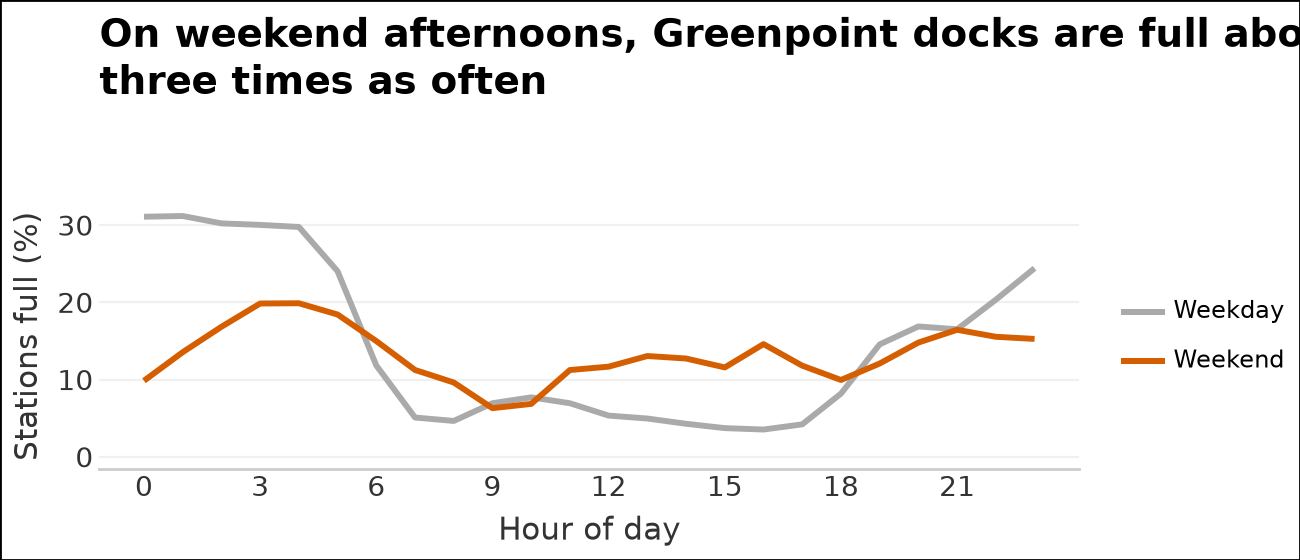

In [36]:
#| label: fig-full-docks
#| echo: false
#| fig-cap: "Share of Greenpoint stations with no open dock, by hour of day. Station status, August 21 to October 1, 2026."
#| fig-width: 6.5
#| fig-height: 2.8

# Read all six weeks, but only the Greenpoint stations and the columns we need
# The station filter is applied while reading, so memory stays small
gp = pd.read_parquet(
    STATUS_DIR,
    filters=[("station_id", "in", greenpoint["station_id"].tolist())],
    columns=["station_id", "fetched_at", "num_docks_available", "is_installed", "is_returning"],
)

# Keep stations that were live, and convert UTC to New York time
gp = gp[gp["is_installed"] & gp["is_returning"]].copy()
gp["t"] = gp["fetched_at"].dt.tz_localize("UTC").dt.tz_convert("America/New_York")
gp["hour"] = gp["t"].dt.hour
gp["day_type"] = np.where(gp["t"].dt.dayofweek >= 5, "Weekend", "Weekday")

# A station is full when it has zero open docks
gp["full"] = gp["num_docks_available"] == 0

# Percent of station snapshots that were full, per hour and day type
full_by_hour = (
    gp.groupby(["day_type", "hour"], as_index=False)["full"].mean()
      .assign(pct_full=lambda d: 100 * d["full"])
)

(
    ggplot(full_by_hour, aes("hour", "pct_full", color="day_type"))
    + geom_line(size=1.2)
    + scale_color_manual(values={"Weekday": "#AAAAAA", "Weekend": "#D55E00"})
    + scale_x_continuous(breaks=range(0, 24, 3))
    + expand_limits(y=0)                      # start the axis at zero
    + labs(
        title=wrap_title("On weekend afternoons, Greenpoint docks are full about three times as often"),
        x="Hour of day",
        y="Stations full (%)",
    )
    + theme_knaflic()
    + theme(figure_size=(6.5, 2.8))           # wide and short, to save page space
)

@fig-full-docks shows how often Greenpoint stations had no open dock in our own data.

In [37]:
# Average percent full from noon through 5 pm, by day type
midday = full_by_hour[full_by_hour["hour"].between(12, 17)]
print(midday.groupby("day_type")["pct_full"].mean().round(1))

day_type
Weekday     4.3
Weekend    12.6
Name: pct_full, dtype: float64


In [38]:
#| label: weekend-by-date
#| include: false

# Percent of Greenpoint station snapshots that were full, per weekend day
# Daytime hours only (11 am through 6 pm), so the weekends can be compared
wk = gp[(gp["day_type"] == "Weekend") & gp["hour"].between(11, 18)].copy()
wk["date"] = wk["t"].dt.date

by_date = (
    wk.groupby("date")["full"].mean().mul(100).round(1)
      .rename("pct_full").reset_index()
)
by_date["day"] = pd.to_datetime(by_date["date"]).dt.day_name()
print(by_date.to_string(index=False))

      date  pct_full      day
2026-08-22      15.2 Saturday
2026-08-23      15.7   Sunday
2026-08-29       6.5 Saturday
2026-08-30       9.2   Sunday
2026-09-05      14.2 Saturday
2026-09-06      12.0   Sunday
2026-09-12      15.5 Saturday
2026-09-13       5.6   Sunday
2026-09-19      17.8 Saturday
2026-09-20       7.8   Sunday
2026-09-26      12.3 Saturday
2026-09-27      13.2   Sunday


In [39]:
#| label: alerts-diagnose
#| include: false

# Find out why the alerts query came back empty, one filter at a time
import urllib.parse

BASE = "https://data.ny.gov/resource/7kct-peq7.csv"

def soda(**params):
    """Run one query against the MTA alerts dataset and return a DataFrame."""
    query = urllib.parse.urlencode({"$" + k: v for k, v in params.items()})
    return pd.read_csv(BASE + "?" + query)

# 1. What dates does the dataset cover?
print(soda(select="min(date) as first, max(date) as last, count(*) as n"))

# 2. How many alerts fall in our window, with no line filter?
window = "date between '2026-08-17T00:00:00' and '2026-10-02T00:00:00'"
print(soda(select="count(*) as n", where=window))

# 3. What do the most recent rows look like?
pd.set_option("display.max_colwidth", 120)
display(soda(select="date, agency, status_label, affected, header", order="date DESC", limit=10))

                     first                     last       n
0  2020-04-28T13:08:00.000  2026-08-12T01:08:00.000  525083
   n
0  0


,date,agency,status_label,affected,header
0,2026-08-12T01:08:00.000,BT,planned-work,Hugh L. Carey Tunnel,HLC: PLANNED WORK; One tube is closed; the remaining tube will run two-way traffic operation.
1,2026-08-11T23:57:00.000,LIRR,cancellations,Port Jefferson Branch,There are two cancellations on the Port Jefferson Branch due to a train with equipment trouble at Smithtown.
2,2026-08-11T23:52:00.000,MNR,some-delays,Danbury,The 6:45pm train from Danbury to Stamford is operating 10-15 minutes late because of congestion on the branch.
3,2026-08-11T23:51:00.000,NYCT Subway,delays,Q,Q trains are running with delays in both directions after we moved a train that had its brakes activated at 72 St.
4,2026-08-11T23:48:00.000,LIRR,cancellations,Port Jefferson Branch,There are two cancellations on the Port Jefferson Branch due to a train with equipment trouble at Smithtown.
5,2026-08-11T23:46:00.000,NYCT Subway,delays,Q,Q trains are delayed in both directions while we investigate what caused a train's brakes to be activated at 72 St.
6,2026-08-11T23:38:00.000,NYCT Bus,detour,Q32,Penn Station-bound Q32 buses are detoured due to construction on W 37th St between 6th Ave and 7th Ave.
7,2026-08-11T23:35:00.000,MNR,some-delays,Danbury,The 6:17pm train from Grand Central to Danbury is operating 10-15 minutes late because of congestion resulting from ...
8,2026-08-11T23:34:00.000,MNR,some-delays,New Haven,The 6:26pm train from Grand Central to New Haven is operating 10-15 minutes late because of congestion resulting fro...
9,2026-08-11T23:34:00.000,NYCT Subway,delays,Q,Downtown Q trains are delayed while we investigate what caused a train's brakes to be activated at 72 St.


## 2. What data sources are you planning to use, and which if any external data sources will you add? Each project is required to add at least one additional data set/data source and make it available as a documented table in the shared catalog for other teams to potentially use.



**Data Sources**

We use four sources the class already provides and add two from the MTA.

| Source | Origin | Grain | Role |
|:---|:---|:---|:---|
| Station status | Class workspace, GBFS | Station, every 5 minutes | Full and empty docks, live demand |
| Station information | Class workspace, GBFS | Station, daily | Location, capacity, id bridge |
| Trip history | BigQuery or Citi Bike [8] | One row per trip | Demand: hourly departures and arrivals |
| Weather | BigQuery | By hour or day | Control for rain and temperature |
| **MTA service alerts** | NY Open Data [9] | One row per alert update | Shutdown events |
| **MTA subway GTFS** | MTA [10][12] | One row per stop | Subway stop coordinates |

: Data sources. New external sources are in bold. {#tbl-sources}

**Existing data.** Trips measure demand. Station status measures the consequence: a station with zero open docks is full. Station information links the two, because trips and status use different station identifiers. A first look at the class data shows a complete grid of 288 snapshots a day across about 2,500 stations.

**New data.** The MTA publishes its service alerts since April 2020 as open data: about 525,000 alert updates, with the affected lines, a status label, and the alert text [9]. The static GTFS feed gives the coordinates of every subway stop [10][12]. Together they tell us which stops lost service and when. The open dataset lags. When we queried it on October 4, 2026, it ended on August 12. So it serves as history. For current closures we read the live MTA alerts feed, which carries current and future alerts [10], and we archive it daily from the start, because the feed keeps no record of past alerts.

**Shared catalog table.** We will publish `mta_subway_shutdowns`: one row per shutdown event and affected stop. Columns include the line, stop, coordinates, start and end time, whether the work was planned, and the Citi Bike stations within a quarter mile. Any team that forecasts demand can join it as a feature.

**Known challenge.** The alert date is when the notice was published, not when service stopped. The real window sits in the free text. We will parse it with an LLM, keep rules as a fallback, and check the result against a hand built calendar of G train closures.

## 3. What initial approach/model types will you use to solve the problem?

**Approach and Models**

We build in three steps, from simple to flexible.

**Step 1: Baseline Model**

We will first establish what normal Citi Bike demand looks like at each station. For each station and hour, we will use historical demand from the same hour and day of the week over recent normal weeks. This provides a baseline that every later model has to beat.

**Step 2: Counterfactual Model**

After establishing the baseline, we will build a model to predict how many Citi Bike trips would normally be expected at each station and hour if no nearby subway shutdown occurred. Because the target variable is a count of trips, we will initially use **Poisson Regression** [11] and move to **Gradient Boosted Trees** with a Poisson objective.

Potential predictors will include hour of day, day of week, holidays, weather, station capacity, and each station's normal demand profile. The model will be trained only on station hours with no shutdown nearby and with the station in service, so it learns normal demand and nothing else.

One design rule matters here. The model gets no recent demand lags. Yesterday's demand during a shutdown already contains the shutdown, so a lag would absorb the effect we want to measure.

This prediction represents our **counterfactual demand**: our estimate of what Citi Bike usage would have been if the subway disruption had not occurred.

**Step 3: Effect and Surge**

A Citi Bike station will initially be considered affected if it is within approximately a quarter mile of a subway stop that lost service [6].

**Shutdown Effect = Observed Demand − Counterfactual Demand**

Each estimate comes with an interval taken from the model's errors on normal days. We will examine whether these effects vary based on distance from the affected subway stop, time of day, day of week, and type or duration of disruption. That summary becomes the surge forecast for the next announced shutdown.

**Checks.** Stations far from the closed line serve as a placebo: their estimated effect should sit near zero. We also compare our G train estimate against a difference in differences estimate on the 2024 shutdown. Displaced riders may spill into nearby untreated stations, so we test several distance bands.

## 4. How will you evaluate model performance?



**Evaluation**

A causal effect has no ground truth: we never observe the weekend where the train ran. So we evaluate in three layers.

**Forecast accuracy.** On normal periods the truth exists. We report mean absolute error in trips per station hour and Poisson deviance, against the baseline. Splits are by time, never random: train on earlier weeks, test on later ones, rolled forward. We avoid percentage error because many station hours have zero trips.

**Causal validity.** Three checks:

1. Placebo in space: stations far from the closed line should show no effect.
2. Placebo in time: a fake shutdown placed on a normal weekend should show no effect.
3. Known event: the 2024 G shutdown should show a clear increase near the closed stops, in line with the reported rise of nearly 14 percent [2].

We also check that the 90 percent interval covers about 90 percent of normal observations.

**Surge forecast.** For each shutdown, we compare the surge forecast made before it with the effect measured after it. We also check that the stations we flag are the ones that fill up, using minutes at zero open docks from station status.

**In production.** From November 16 to December 14 a daily job logs forecast error on normal station hours. The G closures scheduled for December weekends [4, 5] give a live test: forecast before, measure after. If the MTA moves those dates, the daily error and placebo checks still run.

##  5. Will model training be online (model updates whenever new data is ingested) or batch (at scheduled intervals)?



**Training: Batch**

Training will be batch, on a schedule. Three reasons:

1. **The data arrives in batches.** Station status lands every 5 minutes, but we model hourly totals. Trip files arrive monthly.
2. **The causal design needs a controlled training set.** The model must never learn from shutdown hours. An online learner would absorb each surge as it happens and erase the effect we want to measure.
3. **Shutdowns are announced days ahead.** Nothing in the use case needs an update within minutes.

| Job | Schedule | What it does |
|:---|:---|:---|
| Alert ingestion | Hourly | Pulls MTA alerts and updates the shutdown table |
| Scoring | Daily | Predicts the counterfactual for the previous day, logs error and effects |
| Surge forecast | On each new planned shutdown | Flags stations and the expected surge |
| Retraining | Weekly | Refits on a rolling window, shutdown hours excluded |

: Scheduled jobs. {#tbl-jobs}

All four run as scheduled jobs in the class workspace, with no manual steps.

Each retrained model is versioned and compared with the current one on the most recent normal week. It replaces the current model only if it does better.

Because trip files arrive after the month ends, daily scoring uses demand derived from station status: drops in bikes available count as departures, rises as arrivals. Trip history remains the source for training on past years and for checking that proxy.

## 6. Do you anticipate any large computational needs? If you think you will need to use large neural network models, LLMs, GPUs/TPUs, make sure to let me know here.

**Computational Needs**

We will run everything on the class workspace, and we have one request.

**Standard compute.** Station status is about 725,000 rows a day. We aggregate it in the class workspace to one row per station and hour, which gives about 22 million rows a year for all 2,500 stations. Databricks runs on Spark, so that step scales without extra resources. Poisson regression and gradient boosted trees train on a table that size in minutes on a CPU cluster. No GPUs and no large neural networks.

**One request: an LLM for alert parsing.** MTA alerts are free text. The closed segment and the time window sit inside sentences, in many phrasings. We plan to use an LLM to turn each alert into a structured row: line, stops, start, and end. The volume is small. It covers planned subway suspensions only, run once for history and then on new alerts each day. A rule based parser is the fallback, and a hand built G train calendar checks both.

**Other resources.** We will parse it with a hosted LLM if the workspace offers one, or with rules if not, and check the result against a hand built calendar of G train closures.

## 7. The key midterm check for this project is the development of a minimally viable product, which will demonstrate feasibility and which you will iteratively improve. What does your minimally viable product look like?

**Minimum Viable Product**

The MVP is the whole pipeline, end to end, for one line: the G train. Every piece is simple. Every piece runs in the class workspace on a schedule.

**What it includes.**

1. **Shutdown table.** G train closures with affected stops, start and end times, and the Citi Bike stations within a quarter mile. Published to the shared catalog.
2. **Demand table.** Hourly departures and arrivals per station, for the G corridor and a set of control stations.
3. **Model.** The baseline and a Poisson regression, trained on normal hours only.
4. **Effect estimate.** Observed minus counterfactual for each closure in our data, with an interval.
5. **Daily job.** Scores the previous day and logs the error.

**What the demo shows.** One closure weekend in Greenpoint. A chart of observed against counterfactual demand by hour. A ranked list of the stations that surged most, next to the minutes each one spent with zero open docks.

**What it leaves out.** Gradient boosted trees, other subway lines, unplanned outages, and the surge forecast for future shutdowns. Those come between the midterm and November 16.

**Main risks.** Parsing alert text into clean time windows. Separating real trips from rebalancing in the status data. Having enough normal weekends to learn from, since the G has been closed on many of them. And a gap in closure dates: the alert history ends before our station status begins, so recent G closures must come from a hand built calendar until our own archive of the live feed catches up.

## References


[1] Metropolitan Transportation Authority, "Service changes on the G line in summer 2024." https://www.mta.info/article/service-changes-g-line-summer-2024

[2] E. Smith, "Citi Bike Is Stranding Cyclists in Greenpoint During G Train Shutdowns," Streetsblog NYC, Aug. 20, 2026.

[3] K. Gerry, "Greenpoint CitiBike riders ask city for more docking stations," News 12 Brooklyn, May 6, 2026.

[4] S. Liebman, "More G train outages worry Greenpoint businesses," Spectrum News NY1, Apr. 28, 2026.

[5] D. Colon, "Another G Train Shutdown Means Greenpoint Needs Better Bus Priority," Streetsblog NYC, Aug. 21, 2026.

[6] H. Younes, A. Nasri, G. Baiocchi, and L. Zhang, "How transit service closures influence bikesharing demand; lessons learned from SafeTrack project in Washington, D.C. metropolitan area," Journal of Transport Geography, vol. 76, pp. 83 to 92, 2019.

[7] M. Saberi, M. Ghamami, Y. Gu, M. H. Shojaei, and E. Fishman, "Understanding the impacts of a public transit disruption on bicycle sharing mobility patterns: A case of Tube strike in London," Journal of Transport Geography, vol. 66, pp. 154 to 166, 2018.

[8] Citi Bike, "System Data." https://citibikenyc.com/system-data

[9] Metropolitan Transportation Authority, "MTA Service Alerts: Beginning April 2020," New York State Open Data. https://catalog.data.gov/dataset/mta-service-alerts-beginning-april-2020

[10] Metropolitan Transportation Authority, "Developer Resources." https://www.mta.info/developers

[11] G. James, D. Witten, T. Hastie, R. Tibshirani, and J. Taylor, An Introduction to Statistical Learning with Applications in Python, Springer, 2023.

[12] Metropolitan Transportation Authority, "MTA Subway Stations." https://data.ny.gov/Transportation/MTA-Subway-Stations/39hk-dx4f/about_data